In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("employees.csv")

df.head()

,employee_id,name,age,gender,city,department,job_title,salary,experience_years,hire_date,birth_date,email
0,1001,Mostafa Mohamed,47,Female,Mansoura,Sales,Team Leader,7193.0,16,2022-04-14,1979-01-01,mostafa.mohamed@company.com
1,1002,Ayman Adel,24,Male,Mansoura,HR,Business Analyst,13415.0,19,2019-03-22,2002-01-01,ayman.adel@company.com
2,1003,Mina Khalil,40,Female,Cairo,Marketing,Support Engineer,18550.0,4,2022-07-02,1986-01-01,mina.khalil@company.com
3,1004,Karim Mohamed,41,Female,Mansoura,HR,Data Analyst,19512.0,1,2018-07-29,1984-12-31,karim.mohamed@company.com
4,1005,Hassan Hassan,53,Male,Ismailia,Marketing,Business Analyst,28833.0,5,2024-04-14,1972-12-31,hassan.hassan@company.com


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Shape: (103, 12)

Columns:
Index(['employee_id', 'name', 'age', 'gender', 'city', 'department',
       'job_title', 'salary', 'experience_years', 'hire_date', 'birth_date',
       'email'],
      dtype='object')

Data Types:
employee_id           int64
name                 object
age                   int64
gender               object
city                 object
department           object
job_title            object
salary              float64
experience_years      int64
hire_date            object
birth_date           object
email                object
dtype: object

Missing Values:
employee_id         0
name                0
age                 0
gender              0
city                3
department          0
job_title           2
salary              3
experience_years    0
hire_date           0
birth_date          0
email               2
dtype: int64

Basic Statistics:
       employee_id         age        salary  experience_years
count    103.00000  103.000000    100.000000     

In [4]:
print(df.head(10))
print("\n-----------------------------\n")
print(df.tail(5))

   employee_id              name  age  gender      city department  \
0         1001   Mostafa Mohamed   47  Female  Mansoura      Sales   
1         1002        Ayman Adel   24    Male  Mansoura         HR   
2         1003       Mina Khalil   40  Female     Cairo  Marketing   
3         1004     Karim Mohamed   41  Female  Mansoura         HR   
4         1005     Hassan Hassan   53    Male  Ismailia  Marketing   
5         1006    Ahmed Hassan     28    Male  Ismailia    Finance   
6         1007       Eslam Salem   54  Female  Mansoura  Marketing   
7         1008       Karim Samir   39    Male       NaN      Sales   
8         1009      Karim Nasser   22  Female  Mansoura         IT   
9         1010      Omar Mohamed   32    Male  Ismailia  Marketing   

              job_title   salary  experience_years   hire_date  birth_date  \
0           Team Leader   7193.0                16  2022-04-14  1979-01-01   
1      Business Analyst  13415.0                19  2019-03-22  2002-01-0

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numeric values with the median
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Fill missing text values with "Unknown"
text_columns = df.select_dtypes(include="object").columns
df[text_columns] = df[text_columns].fillna("Unknown")

# Check the result
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
employee_id         0
name                0
age                 0
gender              0
city                0
department          0
job_title           0
salary              0
experience_years    0
hire_date           0
birth_date          0
email               0
dtype: int64


In [6]:
print("Number of employees:", len(df))

print("\nAverage values:")
print(df.select_dtypes(include=np.number).mean())

print("\nMinimum values:")
print(df.select_dtypes(include=np.number).min())

print("\nMaximum values:")
print(df.select_dtypes(include=np.number).max())

Number of employees: 100

Average values:
employee_id          1050.50
age                    40.89
salary              17970.30
experience_years       10.46
dtype: float64

Minimum values:
employee_id         1001.0
age                   22.0
salary              5384.0
experience_years       0.0
dtype: float64

Maximum values:
employee_id          1100.0
age                    55.0
salary              29323.0
experience_years       20.0
dtype: float64


In [7]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


name:
name
Hassan Hassan     3
Hassan Ibrahim    3
Eslam Salem       2
Tarek Omar        2
Mina Hamed        2
                 ..
Tarek Youssef     1
Ali Mohamed       1
Ahmed Hamed       1
Adam Mahmoud      1
Youssef Gamal     1
Name: count, Length: 87, dtype: int64

gender:
gender
Female    58
Male      42
Name: count, dtype: int64

city:
city
Mansoura      20
Giza          19
Zagazig       15
Cairo         12
Alexandria    11
Ismailia      11
Tanta          9
Unknown        3
Name: count, dtype: int64

department:
department
Marketing     20
IT            18
Sales         16
Support       14
Finance       13
HR            11
Operations     8
Name: count, dtype: int64

job_title:
job_title
Marketing Specialist    13
Sales Representative    12
Business Analyst        11
Support Engineer        11
Team Leader             10
HR Specialist           10
Software Engineer        9
Accountant               9
Data Analyst             8
Project Manager          5
Unknown                  2


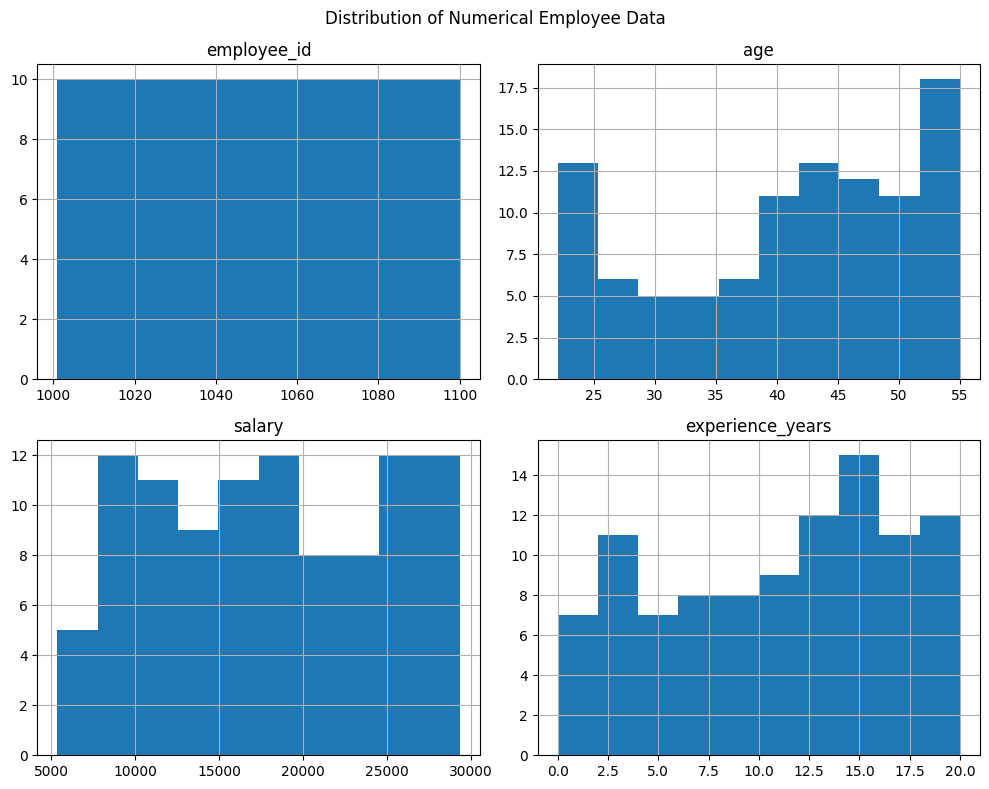

In [8]:
df.select_dtypes(include=np.number).hist(figsize=(10, 8))
plt.suptitle("Distribution of Numerical Employee Data")
plt.tight_layout()
plt.show()

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns
text_columns = df.select_dtypes(include="object").columns

print("Numeric Columns:")
print(list(numeric_columns))

print("\nText Columns:")
print(list(text_columns))

Numeric Columns:
['employee_id', 'age', 'salary', 'experience_years']

Text Columns:
['name', 'gender', 'city', 'department', 'job_title', 'hire_date', 'birth_date', 'email']


In [10]:
for column in numeric_columns:
    print(f"{column}: {df[column].mean():.2f}")

employee_id: 1050.50
age: 40.89
salary: 17970.30
experience_years: 10.46


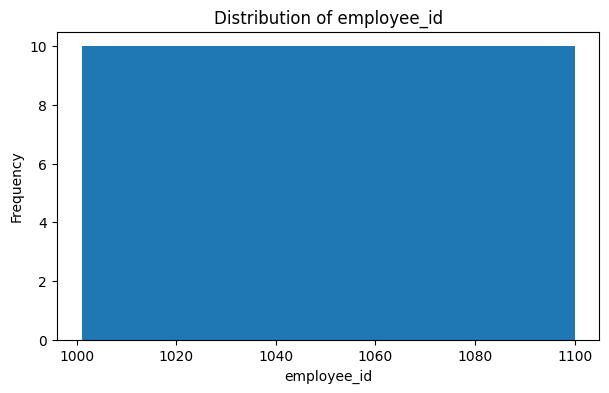

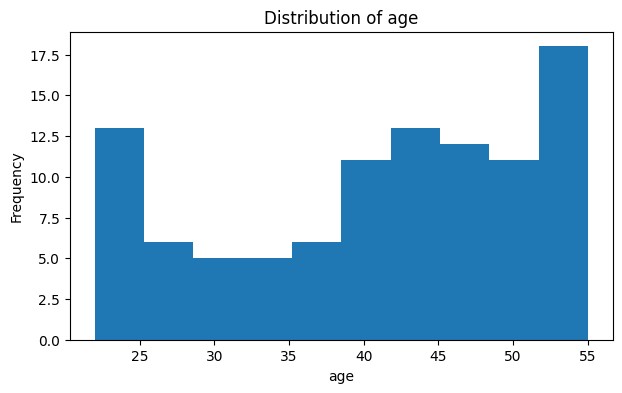

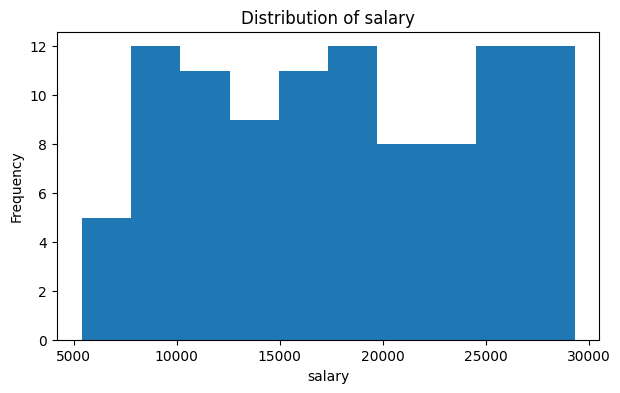

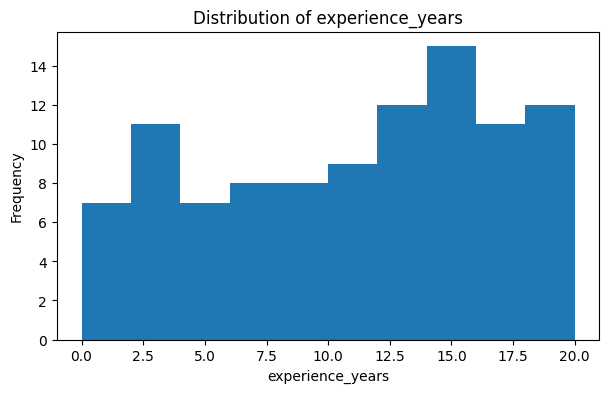

In [11]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=10)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [12]:
for column in text_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- name ---
name
Hassan Hassan     3
Hassan Ibrahim    3
Eslam Salem       2
Tarek Omar        2
Mina Hamed        2
                 ..
Tarek Youssef     1
Ali Mohamed       1
Ahmed Hamed       1
Adam Mahmoud      1
Youssef Gamal     1
Name: count, Length: 87, dtype: int64

--- gender ---
gender
Female    58
Male      42
Name: count, dtype: int64

--- city ---
city
Mansoura      20
Giza          19
Zagazig       15
Cairo         12
Alexandria    11
Ismailia      11
Tanta          9
Unknown        3
Name: count, dtype: int64

--- department ---
department
Marketing     20
IT            18
Sales         16
Support       14
Finance       13
HR            11
Operations     8
Name: count, dtype: int64

--- job_title ---
job_title
Marketing Specialist    13
Sales Representative    12
Business Analyst        11
Support Engineer        11
Team Leader             10
HR Specialist           10
Software Engineer        9
Accountant               9
Data Analyst             8
Project Manager    

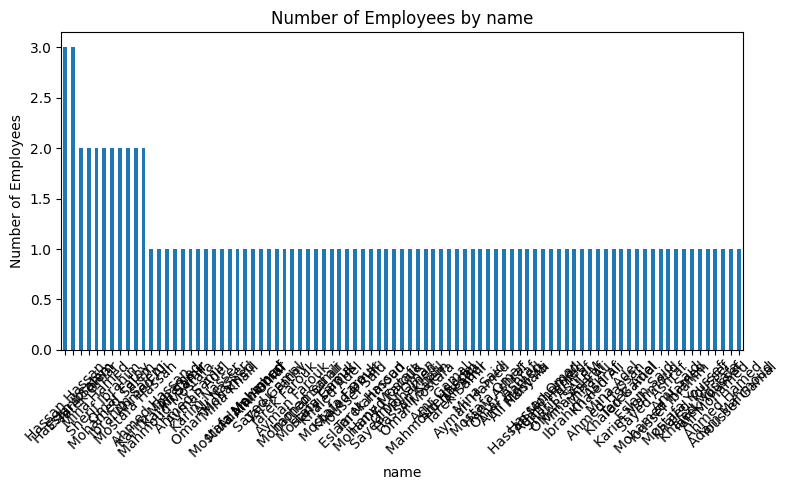

In [13]:
if len(text_columns) > 0:
    column = text_columns[0]

    counts = df[column].value_counts()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title(f"Number of Employees by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

                  employee_id       age    salary  experience_years
employee_id          1.000000  0.166446  0.134891         -0.004841
age                  0.166446  1.000000 -0.015811         -0.081714
salary               0.134891 -0.015811  1.000000         -0.148677
experience_years    -0.004841 -0.081714 -0.148677          1.000000


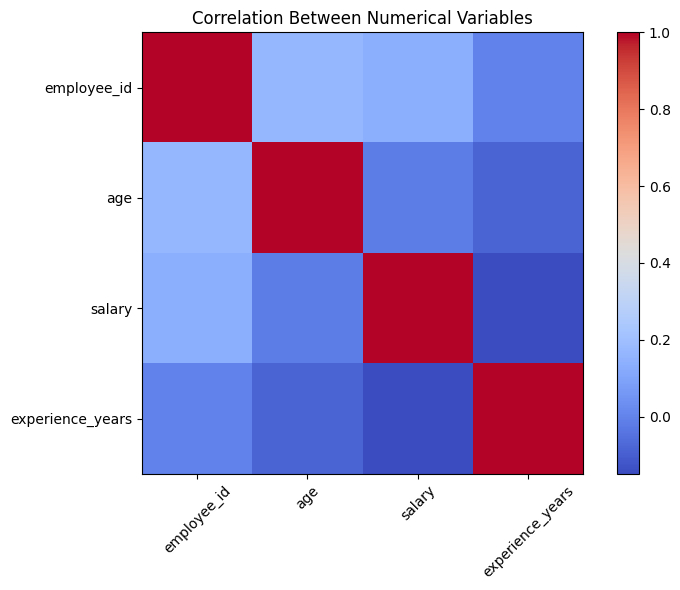

In [14]:
if len(numeric_columns) >= 2:
    correlation = df[numeric_columns].corr()

    print(correlation)

    plt.figure(figsize=(8, 6))
    plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()

    plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
    plt.yticks(range(len(correlation.columns)), correlation.columns)

    plt.title("Correlation Between Numerical Variables")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for correlation analysis.")

In [15]:
summary = {
    "Number of Rows": len(df),
    "Number of Columns": len(df.columns),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum()
}

for key, value in summary.items():
    print(f"{key}: {value}")

Number of Rows: 100
Number of Columns: 12
Missing Values: 0
Duplicate Rows: 0


In [16]:
df.to_csv("employees_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Employee Data Analysis Using Python

## Project Overview
This project analyzes employee data using Python, NumPy, pandas, and Matplotlib.

## Analysis Performed
- Data inspection
- Data cleaning
- Missing values detection
- Duplicate detection
- Statistical analysis
- Numerical data analysis
- Categorical data analysis
- Data visualization
- Correlation analysis

## Tools & Technologies
- Python
- NumPy
- pandas
- Matplotlib

## Conclusion
The analysis provides useful insights into the employee dataset and demonstrates practical data analysis skills using Python.

In [17]:
print("===== EMPLOYEE DATASET INSIGHTS =====")

print("\n1. Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n2. Missing Values:")
print(df.isnull().sum().sum())

print("\n3. Duplicate Rows:")
print(df.duplicated().sum())

print("\n4. Numerical Columns:")
print(list(numeric_columns))

print("\n5. Text Columns:")
print(list(text_columns))

print("\n6. Numerical Summary:")
print(df[numeric_columns].describe())

===== EMPLOYEE DATASET INSIGHTS =====

1. Dataset Shape:
Rows: 100
Columns: 12

2. Missing Values:
0

3. Duplicate Rows:
0

4. Numerical Columns:
['employee_id', 'age', 'salary', 'experience_years']

5. Text Columns:
['name', 'gender', 'city', 'department', 'job_title', 'hire_date', 'birth_date', 'email']

6. Numerical Summary:
       employee_id        age        salary  experience_years
count   100.000000  100.00000    100.000000        100.000000
mean   1050.500000   40.89000  17970.300000         10.460000
std      29.011492   10.29062   6790.397844          5.753207
min    1001.000000   22.00000   5384.000000          0.000000
25%    1025.750000   32.00000  12031.250000          5.750000
50%    1050.500000   43.00000  17763.000000         11.500000
75%    1075.250000   50.00000  23722.500000         15.000000
max    1100.000000   55.00000  29323.000000         20.000000


In [18]:
print("===== CATEGORICAL INSIGHTS =====")

for column in text_columns:
    print(f"\n{column}")
    print(df[column].value_counts().head(10))

===== CATEGORICAL INSIGHTS =====

name
name
Hassan Hassan     3
Hassan Ibrahim    3
Eslam Salem       2
Tarek Omar        2
Mina Hamed        2
Sherif Ibrahim    2
Mohamed Salem     2
Omar Fathy        2
Ibrahim Salem     2
Mostafa Hassan    2
Name: count, dtype: int64

gender
gender
Female    58
Male      42
Name: count, dtype: int64

city
city
Mansoura      20
Giza          19
Zagazig       15
Cairo         12
Alexandria    11
Ismailia      11
Tanta          9
Unknown        3
Name: count, dtype: int64

department
department
Marketing     20
IT            18
Sales         16
Support       14
Finance       13
HR            11
Operations     8
Name: count, dtype: int64

job_title
job_title
Marketing Specialist    13
Sales Representative    12
Business Analyst        11
Support Engineer        11
Team Leader             10
HR Specialist           10
Software Engineer        9
Accountant               9
Data Analyst             8
Project Manager          5
Name: count, dtype: int64

hire

In [19]:
print("===== TOP VALUES =====")

for column in numeric_columns:
    print(f"\nHighest {column}:")
    print(df[column].max())

    print(f"Lowest {column}:")
    print(df[column].min())

    print(f"Average {column}:")
    print(round(df[column].mean(), 2))

===== TOP VALUES =====

Highest employee_id:
1100
Lowest employee_id:
1001
Average employee_id:
1050.5

Highest age:
55
Lowest age:
22
Average age:
40.89

Highest salary:
29323.0
Lowest salary:
5384.0
Average salary:
17970.3

Highest experience_years:
20
Lowest experience_years:
0
Average experience_years:
10.46


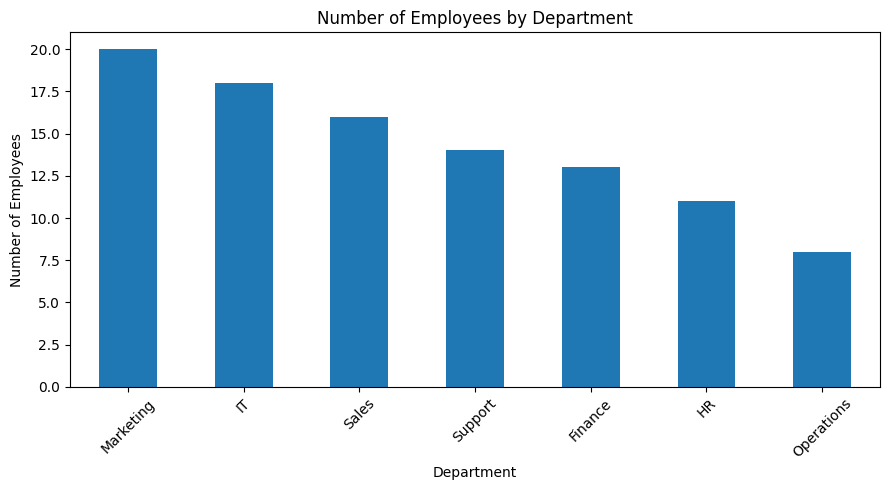

In [20]:
department_counts = df["department"].value_counts()

plt.figure(figsize=(9, 5))
department_counts.plot(kind="bar")

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

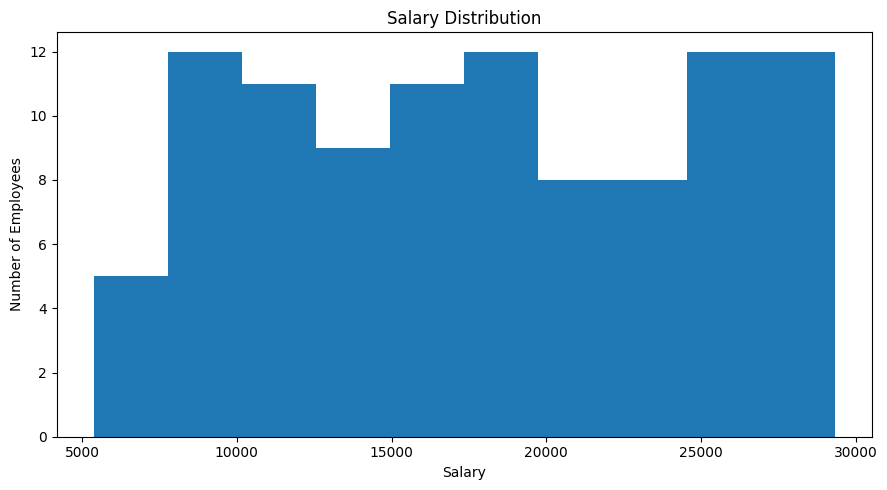

In [21]:
plt.figure(figsize=(9, 5))

plt.hist(df["salary"], bins=10)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

department
Marketing     19575.150000
Operations    18923.250000
Sales         18479.687500
IT            18401.611111
HR            16938.000000
Support       16771.428571
Finance       15855.307692
Name: salary, dtype: float64


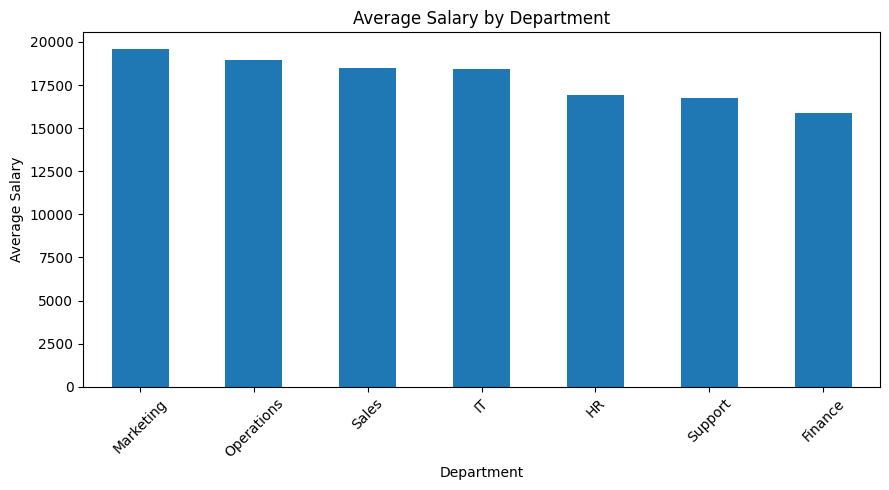

In [22]:
avg_salary_by_department = df.groupby("department")["salary"].mean().sort_values(ascending=False)

print(avg_salary_by_department)

plt.figure(figsize=(9, 5))

avg_salary_by_department.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

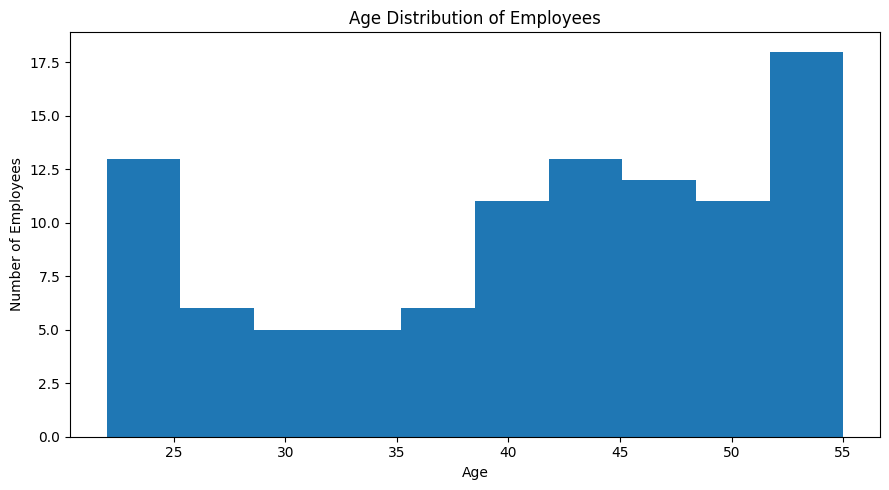

In [23]:
plt.figure(figsize=(9, 5))

plt.hist(df["age"], bins=10)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

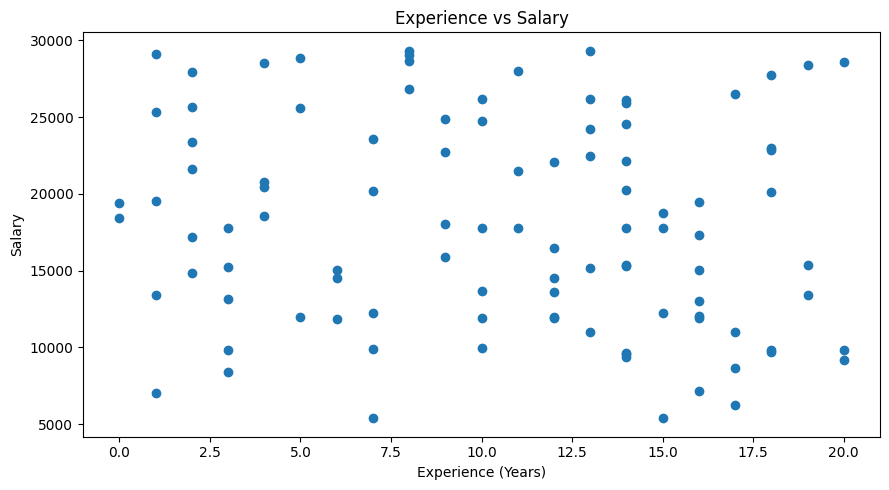

In [24]:
plt.figure(figsize=(9, 5))

plt.scatter(df["experience_years"], df["salary"])

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

gender
Female    58
Male      42
Name: count, dtype: int64


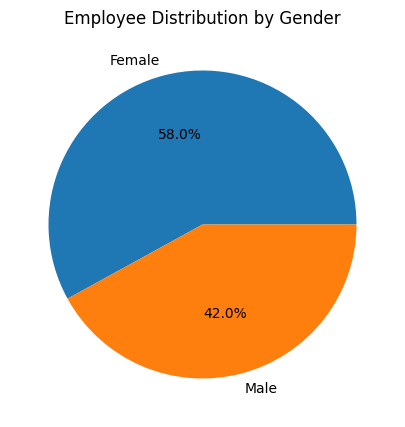

In [25]:
gender_counts = df["gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(7, 5))

gender_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Employee Distribution by Gender")
plt.ylabel("")

plt.show()

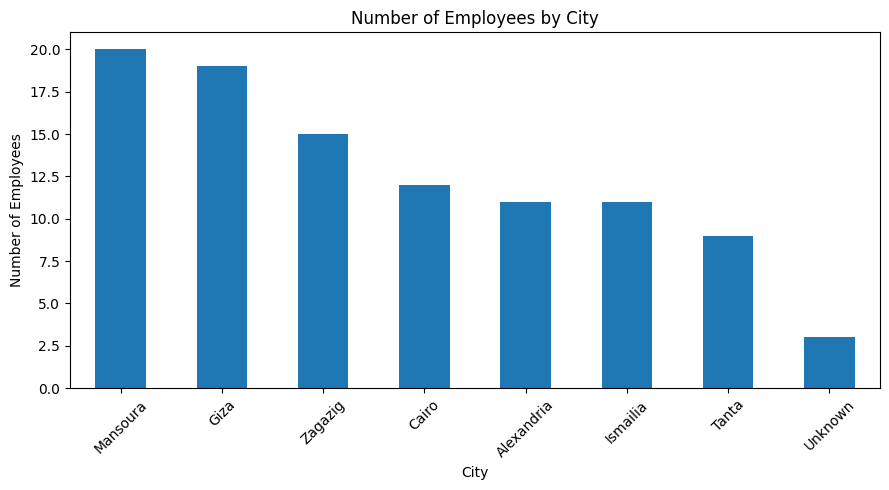

In [26]:
city_counts = df["city"].value_counts()

plt.figure(figsize=(9, 5))

city_counts.plot(kind="bar")

plt.title("Number of Employees by City")
plt.xlabel("City")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Key Insights

- The dataset contains 100 employees and 12 columns.
- No missing values or duplicate rows were found after data cleaning.
- The average employee age is 40.89 years.
- The average salary is 17,970.30.
- The average experience is 10.46 years.
- The Marketing department has the highest number of employees with 20 employees.
- Female employees represent 58% of the dataset, while male employees represent 42%.
- Mansoura has the highest number of employees with 20 employees.
- Employee salaries range from 5,384 to 29,323.
- Employee experience ranges from 0 to 20 years.
- The analysis also explored the relationship between experience and salary using a scatter plot.

# Conclusion

This project provided practical experience in analyzing employee data using Python, NumPy, pandas, and Matplotlib.

The analysis included data inspection, data cleaning, statistical analysis, categorical analysis, and data visualization.

The results helped identify important patterns related to employee age, salary, experience, gender, departments, and cities.

In [27]:
public_df = df.drop(columns=["name", "email", "birth_date"], errors="ignore")

public_df.to_csv("employees_portfolio.csv", index=False)

print("Public portfolio dataset created successfully!")
print(public_df.head())

Public portfolio dataset created successfully!
   employee_id  age  gender      city department         job_title   salary  \
0         1001   47  Female  Mansoura      Sales       Team Leader   7193.0   
1         1002   24    Male  Mansoura         HR  Business Analyst  13415.0   
2         1003   40  Female     Cairo  Marketing  Support Engineer  18550.0   
3         1004   41  Female  Mansoura         HR      Data Analyst  19512.0   
4         1005   53    Male  Ismailia  Marketing  Business Analyst  28833.0   

   experience_years   hire_date  
0                16  2022-04-14  
1                19  2019-03-22  
2                 4  2022-07-02  
3                 1  2018-07-29  
4                 5  2024-04-14  
